In [1]:
#분류모델을 적용하면 변수가 너무 많아서 회귀로 처리

In [2]:
from PIL import Image
import glob

all_images = []
img_size = (32, 20)
labels = []
for f in glob.glob('c:\\data\\power\\**\\*.jpg', recursive=True):
    arr = f.split('\\')
    img = Image.open(f)
    img_resize = img.resize((img_size[0], img_size[1]))
    all_images.append(img_resize)
    label = float(arr[3])
    labels.append(label)

In [3]:
###############################
labels[:10]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [4]:
###############################
len(labels)

12319

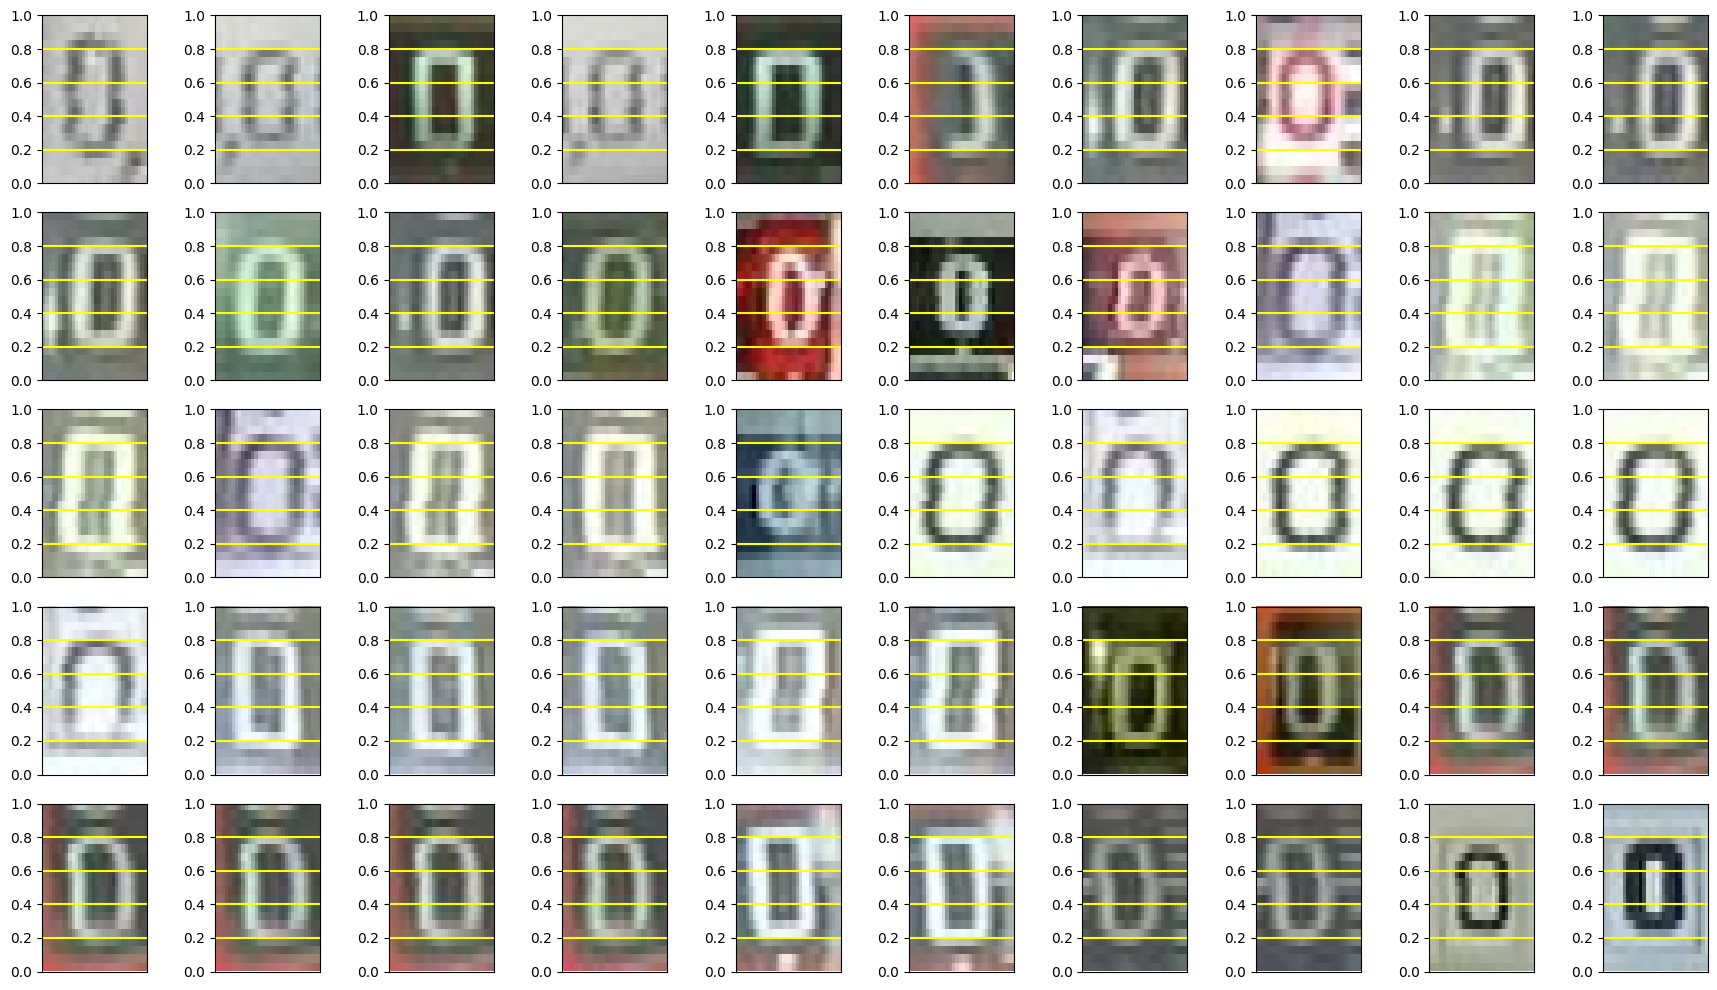

In [5]:
###############################
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 10))
columns = 10
rows = 5
for i in range(1, columns * rows + 1):
    if i > len(all_images):
        break
    fig.add_subplot(rows, columns, i)
    plt.xticks([0.2, 0.4, 0.6, 0.8])
    # aspect='1.6' 실제 이미지의 1.6배(축척 조정)
    # extent=(xmin,xmax,ymin,ymax) x,y 축의 범위
    plt.imshow((all_images[i - 1]), aspect='1.6', extent=[0, 1, 0, 1])
    for y in np.arange(0.2, 0.8, 0.2):
        plt.axhline(y=y, color='yellow')
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    plt.tight_layout()

plt.show()

In [6]:
###############################
a = ['a', 'b', 'c', 'b', 'c']
np.unique(labels, return_inverse=True)
# (array(['a', 'b', 'c'], dtype='<U1'), array([0, 1, 2, 1, 2], dtype=int64))
# 유일한 값은 'a','b','c'
# 인덱스       0   1   2 를 원래 리스트 a에 인덱스 부여

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
        5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
        6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
        7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ,
        9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9]),
 array([ 0,  0,  0, ..., 99, 99, 99], shape=(12319,)))

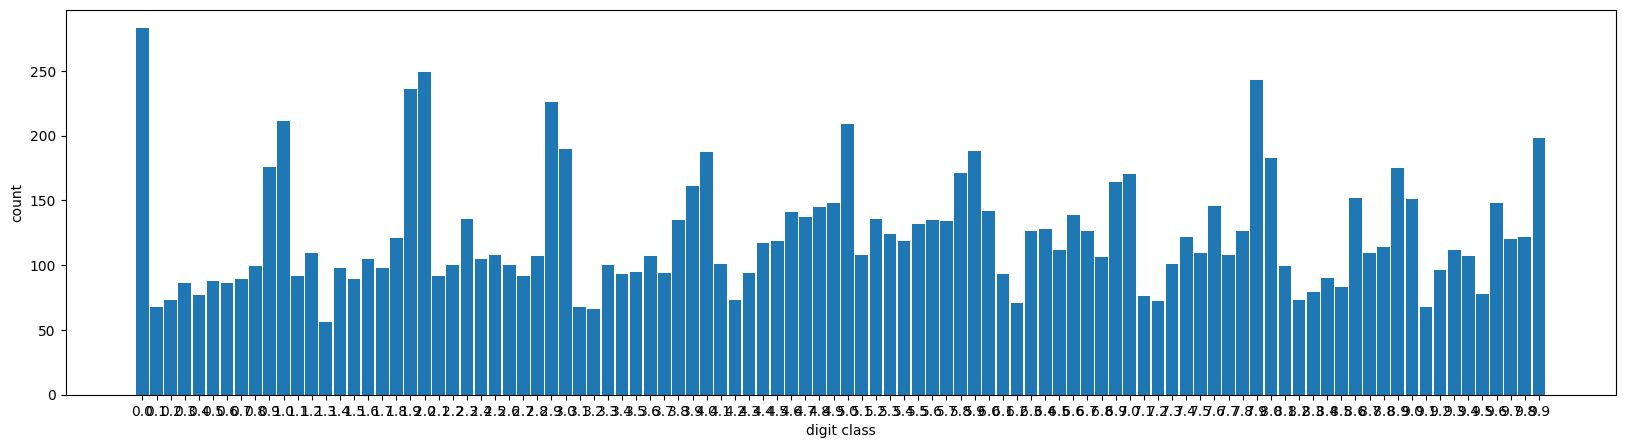

In [7]:
###############################
#unique 중복값 제거하고 대표값만 출력
_, inverse = np.unique(labels, return_inverse=True)
data_bincount = np.bincount(inverse)
plt.figure(figsize=(20, 5))
plt.bar(np.arange(0, 10, 0.1), data_bincount, width=0.09, align='center')
plt.ylabel('count')
plt.xlabel('digit class')
plt.xticks(np.arange(0, 10, 0.1))
plt.show()

In [8]:
###############################
#오래걸림
X = np.empty((1, img_size[0], img_size[1], 3))
for img in all_images[::10]:
    X = np.vstack((X, np.array(img).reshape(1, img_size[0], img_size[1], 3)))
X.shape

(1233, 32, 20, 3)

In [9]:
###############################
X = np.delete(X, (0), axis=0)

In [10]:
###############################
X.shape

(1232, 32, 20, 3)

In [11]:
###############################
x_data = X / 255.
x_data

array([[[[0.71764706, 0.72156863, 0.69803922],
         [0.71764706, 0.72156863, 0.69803922],
         [0.72156863, 0.7254902 , 0.69803922],
         ...,
         [0.78823529, 0.79215686, 0.76862745],
         [0.81960784, 0.82352941, 0.8       ],
         [0.80392157, 0.80784314, 0.78431373]],

        [[0.8       , 0.80392157, 0.78039216],
         [0.81176471, 0.81568627, 0.79215686],
         [0.77647059, 0.78039216, 0.75686275],
         ...,
         [0.74117647, 0.74509804, 0.7254902 ],
         [0.74509804, 0.74901961, 0.7254902 ],
         [0.75686275, 0.76078431, 0.74117647]],

        [[0.77647059, 0.78039216, 0.76078431],
         [0.79215686, 0.79607843, 0.77647059],
         [0.80392157, 0.80784314, 0.78823529],
         ...,
         [0.78823529, 0.78823529, 0.76078431],
         [0.8       , 0.8       , 0.76862745],
         [0.80392157, 0.80392157, 0.77254902]],

        ...,

        [[0.78431373, 0.78431373, 0.78431373],
         [0.76470588, 0.76470588, 0.76470588]

In [12]:
###############################
y_data = np.array(labels[::10])
y_data

array([0. , 0. , 0. , ..., 9.9, 9.9, 9.9], shape=(1232,))

In [13]:
###############################
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, shuffle=True, random_state=10)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((985, 32, 20, 3), (247, 32, 20, 3), (985,), (247,))

In [14]:
###############################
from keras.models import Sequential
from keras.layers import *

model = Sequential()
model.add(BatchNormalization(input_shape=(32, 20, 3)))  # 미니배치의 출력값을 정규화
model.add(Conv2D(32, (3, 3), padding='same', activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Conv2D(32, (3, 3), padding='same', activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Conv2D(32, (3, 3), padding='same', activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.4))
#회귀분석은 출력층에서 활성화함수 없음 or activation='linear'
model.add(Dense(1, activation=None))
model.compile(loss='mae', optimizer="adam", metrics=["mae"])
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 32, 20, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 20, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 5, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,813 (206.30 KB)

 Trainable params: 52,615 (205.53 KB)

 Non-trainable params: 198 (792.00 B)

In [15]:
###############################
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("c:/data/models/power_best.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
hist = model.fit(X_train, y_train, batch_size=32, validation_split=0.2, epochs=100, callbacks=[checkpoint])

Epoch 1/100
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4702 - mae: 4.4702
Epoch 1: val_loss improved from None to 5.16173, saving model to c:/data/models/power_best.keras

Epoch 1: finished saving model to c:/data/models/power_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 3.4415 - mae: 3.4415 - val_loss: 5.1617 - val_mae: 5.1617
Epoch 2/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9055 - mae: 2.9055
Epoch 2: val_loss did not improve from 5.16173
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.8761 - mae: 2.8761 - val_loss: 5.2052 - val_mae: 5.2052
Epoch 3/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7291 - mae: 2.7291
Epoch 3: val_loss improved from 5.16173 to 4.75270, saving model to c:/data/models/power_best.keras

Epoch 3: finished saving model to c:/data/models/power_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.6876 - mae: 2.6876 - val_loss: 4.7527 - val_mae: 4.7527
Epoch 4/100
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2

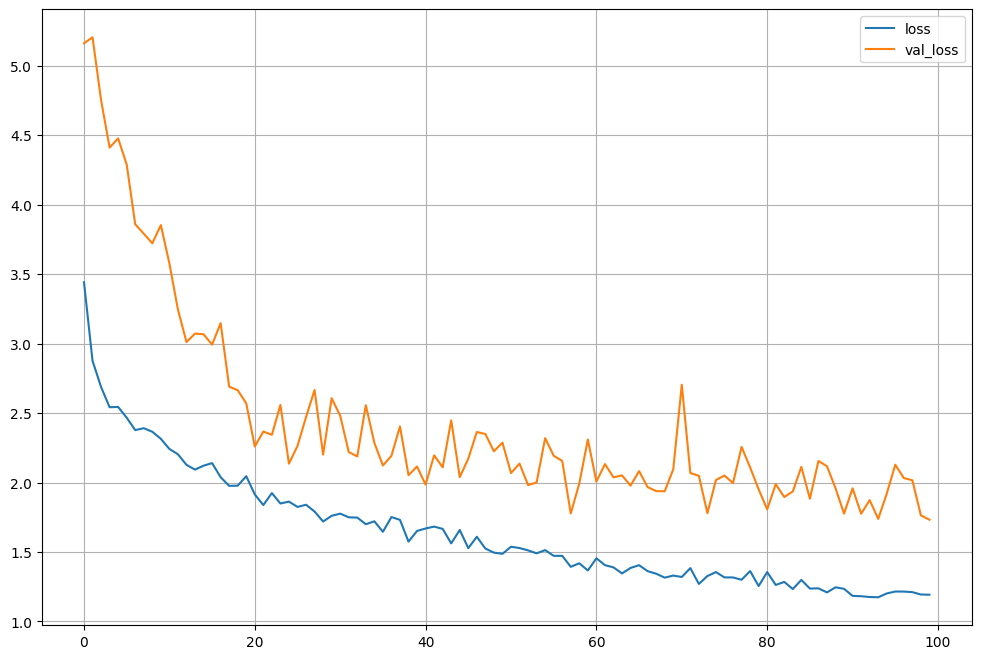

In [16]:
###############################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.grid()
plt.show()

In [17]:
###############################
from tensorflow.keras.models import load_model

model = load_model('c:/data/models/power_best.keras')
scores = model.evaluate(X_train, y_train, verbose=1)
print(scores)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8656 - mae: 0.8656
[0.8656197786331177, 0.8656197786331177]


In [18]:
###############################
scores = model.evaluate(X_test, y_test, verbose=1)
print(scores)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5943 - mae: 1.5943 
[1.5942813158035278, 1.5942813158035278]


In [19]:
###############################
pred = model.predict(X_test)
pred[:5]

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([[0.41231298],
       [5.760046  ],
       [5.933522  ],
       [4.9619374 ],
       [6.0902987 ]], dtype=float32)

In [20]:
###############################
y_test[:5]

array([1. , 5.6, 9.1, 6.2, 5.8])